
# Machine Precision & Floating-Point Pitfalls

This is a tour of "IEEE-754" double precision (Python/NumPy `float64`).  
Run cells top-to-bottom, or skip around. Each section is short and self-contained.



**Contents**
1. What is machine epsilon? (`eps`, `ULP`, `nextafter`)
2. Rounding makes arithmetic **non-associative**
3. Catastrophic cancellation
4. Stable vs unstable formulas (`(1 - cos x) / x^2`)
5. Decimal vs binary representation surprises
6. Bonus: building intuition with plots


## 1) Machine epsilon, ULP, and neighbors

In [ ]:

import numpy as np

# IEEE-754 info for float64
fi = np.finfo(np.float64)
fi


In [1]:

# Classic empirical epsilon finder
eps = 1.0
while 1.0 + eps/2.0 > 1.0:
    eps /= 2.0
eps


2.220446049250313e-16

In [ ]:

# Nearest floating neighbors around 1.0 and around a large number
a = 1.0
b = 1e16

neighbor_up_1 = np.nextafter(a, np.inf)
neighbor_down_1 = np.nextafter(a, -np.inf)

neighbor_up_b = np.nextafter(b, np.inf)
neighbor_down_b = np.nextafter(b, -np.inf)

print("Around 1.0:")
print("  nextafter(1.0, +inf) :", neighbor_up_1)
print("  nextafter(1.0, -inf) :", neighbor_down_1)
print("  ULP(1.0)              :", neighbor_up_1 - a)

print("\nAround 1e16:")
print("  nextafter(1e16, +inf):", neighbor_up_b)
print("  nextafter(1e16, -inf):", neighbor_down_b)
print("  ULP(1e16)             :", neighbor_up_b - b)


In [ ]:

# Demonstrate that (1 + eps) - 1 may be zero for tiny eps (relative to the current magnitude)
small = 1e-16
print("(1 + 1e-16) - 1 =", (1.0 + small) - 1.0)

huge = 1e16
tiny = 1.0
print("\n(1e16 + 1.0) - 1e16 =", (huge + tiny) - huge, "   <-- tiny increment lost due to large ULP")


## 2) Rounding → arithmetic is **non-associative**

In [ ]:

x = 1e16
y = -1e16
z = 1.0

left = (x + y) + z      # ideally 1.0
right = x + (y + z)     # may lose the 1.0 when y+z rounds to y

print("(x + y) + z =", left)
print("x + (y + z) =", right)


## 3) Catastrophic cancellation

In [ ]:

# Subtract nearly equal numbers
p = 0.12345678901234567
q = 0.12345678901234566
exact = p - q
naive = (p + 1e-17) - (q + 1e-17)  # same exact difference, but less stable numerically at different scales

print("Exact-ish difference (double precision):", exact)
print("Same difference at different scale:", naive)


## 4) Stable vs unstable formulas


###  `(1 - cos x) / x^2` for small `x`

Naively, numerator suffers catastrophic cancellation.  
Use the identity \(1 - \cos x = 2\sin^2(x/2)\) for stability.


In [ ]:

import numpy as np
import matplotlib.pyplot as plt

def f_naive(x):
    return (1 - np.cos(x)) / x**2

def f_stable(x):
    return 2 * (np.sin(x/2))**2 / x**2

xs = np.logspace(-16, -1, 100)
y1 = f_naive(xs)
y2 = f_stable(xs)

plt.figure()
plt.loglog(xs, np.abs(y1 - 0.5), label="|naive - 0.5|")
plt.loglog(xs, np.abs(y2 - 0.5), label="|stable - 0.5|")
plt.xlabel("x")
plt.ylabel("absolute error to 0.5")
plt.title("Cancellation in (1 - cos x) / x^2")
plt.legend()
plt.show()


## 5) Decimal vs binary representation

In [ ]:

# 0.1 is not exactly representable in binary floating point
a = 0.1 + 0.2
b = 0.3

print("0.1 + 0.2 =", a)
print("0.3       =", b)
print("Are they exactly equal?", a == b)
print("Absolute difference:", abs(a - b))


## 6) Relative error constant with magnitude (ULP scales)

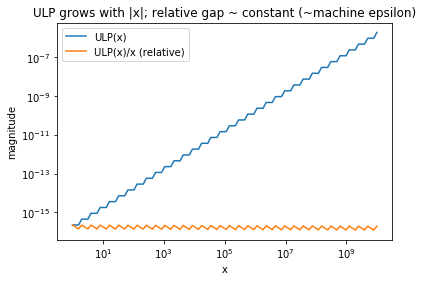

In [8]:

import numpy as np
import matplotlib.pyplot as plt

vals = np.logspace(0, 10, 100)  # 1 to 1e10
ulps = np.nextafter(vals, np.inf) - vals
rel = ulps / vals

plt.figure()
plt.loglog(vals, ulps, label="ULP(x)")
plt.loglog(vals, rel, label="ULP(x)/x (relative)")
plt.xlabel("x")
plt.ylabel("magnitude")
plt.title("ULP grows with |x|; relative gap ~ constant (~machine epsilon)")
plt.legend()
plt.show()



## Summary

- **Machine epsilon** (~2.22e-16 for `float64`) is the *typical* relative spacing near 1.  
- Arithmetic is **not associative**; re-ordering operations can change results.  
- **Catastrophic cancellation**: subtracting nearly equal numbers loses significant digits.  
- Prefer **stable formulas** (e.g., `2*sin(x/2)^2` over `1-cos x`).    
- Binary cannot represent most **decimal fractions** exactly (e.g., 0.1).

**Try:** Modify sizes, orders, and parameters and watch the rounding behavior change.
